In [2]:
# 1. Visualisation des données 
#Étape 1 : Ensemble de données Charger 

import pandas as pd
import os

# Afficher le répertoire courant
print(os.getcwd())

# Charger le dataset avec le chemin complet
df = pd.read_excel("dataset.xlsx")

# Afficher les 5 premières lignes
print(df.head())

c:\Users\HP\Desktop\data-mining-project
   ID  Gender  Age_Categories  Income  Marital_Status  Carer  Parent  \
0  29       1               8     1.0               4    1.0     2.0   
1  41       2               8     3.0               7    1.0     2.0   
2  53       1               7     2.0               4    1.0     2.0   
3  78       2               7     2.0               7    1.0     2.0   
4  83       1               7     1.0               1    1.0     1.0   

   UCLA_Single_Frequency  UCLA_Comp_Often  UCLA_Leftout_Often  ...  \
0                      1              1.0                 1.0  ...   
1                      4              5.0                 5.0  ...   
2                      3              4.0                 3.0  ...   
3                      3              4.0                 2.0  ...   
4                      5              4.0                 2.0  ...   

   When_Young  When_Young_Adult  When_Adult  When_Mid_Life  When_Older_Adult  \
0           0             

In [3]:
# Étape 2 : Informations générales
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6708 entries, 0 to 6707
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     6708 non-null   int64  
 1   Gender                 6708 non-null   int64  
 2   Age_Categories         6708 non-null   int64  
 3   Income                 6626 non-null   float64
 4   Marital_Status         6708 non-null   int64  
 5   Carer                  6570 non-null   float64
 6   Parent                 6575 non-null   float64
 7   UCLA_Single_Frequency  6708 non-null   int64  
 8   UCLA_Comp_Often        6459 non-null   float64
 9   UCLA_Leftout_Often     6427 non-null   float64
 10  UCLA_Isolated_Often    6382 non-null   float64
 11  Times_Alone            6360 non-null   float64
 12  Other_Times            6352 non-null   float64
 13  Health_Self_Rating     6708 non-null   int64  
 14  Social_Capital         5398 non-null   float64
 15  When

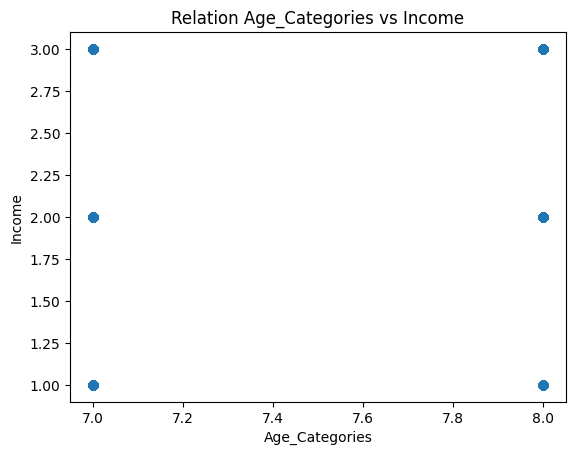

In [ ]:
#Étape 3 : Visualisation du nuage de points

import matplotlib.pyplot as plt
figure, axe = plt.subplots()

# utiliser la colonne Age_Categories et supprimer les lignes sans Income
sub = df[['Age_Categories', 'Income']].dropna()
axe.scatter(sub['Age_Categories'], sub['Income'])

axe.set_title("Relation Age_Categories vs Income")
axe.set_xlabel("Age_Categories")
axe.set_ylabel("Income")

plt.show()


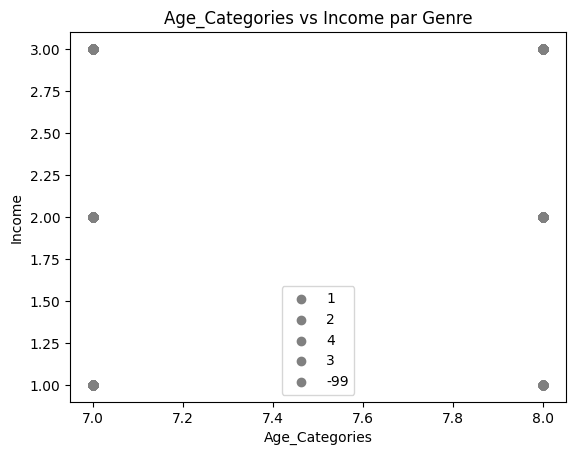

In [16]:
#Étape 4 : Visualisation avec différentes couleurs (en tant que catégorie variable)
colors = {'Male':'blue', 'Female':'red'}

plt.figure()

for gender in df['Gender'].unique():
    subset = df[df['Gender'] == gender]
    plt.scatter(subset['Age_Categories'],
                subset['Income'],
                c=colors.get(gender, 'gray'),
                label=gender)

plt.title("Age_Categories vs Income par Genre")
plt.xlabel("Age_Categories")
plt.ylabel("Income")
plt.legend()
plt.show()

In [17]:
#2. PRÉTRAITEMENT DES DONNEES

#(a) Vérifier les doublons

print("Nombre de doublons :", df.duplicated().sum())

# Supprimer les doublons
df = df.drop_duplicates()

Nombre de doublons : 0


In [18]:
#(b) Vérifier les valeurs manquantes
print(df.isnull().sum())


ID                          0
Gender                      0
Age_Categories              0
Income                     82
Marital_Status              0
Carer                     138
Parent                    133
UCLA_Single_Frequency       0
UCLA_Comp_Often           249
UCLA_Leftout_Often        281
UCLA_Isolated_Often       326
Times_Alone               348
Other_Times               356
Health_Self_Rating          0
Social_Capital           1310
When_Young                  0
When_Young_Adult            0
When_Adult                  0
When_Mid_Life               0
When_Older_Adult            0
UCLA3_tot                 394
Other_times_count         356
UCLA3_gp                  394
Marital_Stat3             134
SRH_gp                   1280
dtype: int64


In [20]:
#(c) Supprimer toutes les lignes contenu des valeurs manquantes
df2 = df.dropna()

print(df2.info())

<class 'pandas.core.frame.DataFrame'>
Index: 5215 entries, 0 to 6356
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     5215 non-null   int64  
 1   Gender                 5215 non-null   int64  
 2   Age_Categories         5215 non-null   int64  
 3   Income                 5215 non-null   float64
 4   Marital_Status         5215 non-null   int64  
 5   Carer                  5215 non-null   float64
 6   Parent                 5215 non-null   float64
 7   UCLA_Single_Frequency  5215 non-null   int64  
 8   UCLA_Comp_Often        5215 non-null   float64
 9   UCLA_Leftout_Often     5215 non-null   float64
 10  UCLA_Isolated_Often    5215 non-null   float64
 11  Times_Alone            5215 non-null   float64
 12  Other_Times            5215 non-null   float64
 13  Health_Self_Rating     5215 non-null   int64  
 14  Social_Capital         5215 non-null   float64
 15  When_Youn

In [22]:
#(d) Supprimer uniquement les valeurs manquantes d'une colonne
df3 = df.dropna(subset=['Age_Categories'])

In [27]:
#(e) Remplacer les valeurs manquantes
# Remplacer Age_Categories par la médiane
df['Age_Categories'].fillna(df['Age_Categories'].median(), inplace=True)

In [28]:
print(df['Age_Categories'].isnull().sum())

0


In [29]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6708 entries, 0 to 6707
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     6708 non-null   int64  
 1   Gender                 6708 non-null   int64  
 2   Age_Categories         6708 non-null   int64  
 3   Income                 6626 non-null   float64
 4   Marital_Status         6708 non-null   int64  
 5   Carer                  6570 non-null   float64
 6   Parent                 6575 non-null   float64
 7   UCLA_Single_Frequency  6708 non-null   int64  
 8   UCLA_Comp_Often        6459 non-null   float64
 9   UCLA_Leftout_Often     6427 non-null   float64
 10  UCLA_Isolated_Often    6382 non-null   float64
 11  Times_Alone            6360 non-null   float64
 12  Other_Times            6352 non-null   float64
 13  Health_Self_Rating     6708 non-null   int64  
 14  Social_Capital         5398 non-null   float64
 15  When

In [34]:
#Colonnes numériques → remplaçant par la MÉDIANE
for col in df.select_dtypes(include=['int64','float64']).columns:
    df[col].fillna(df[col].median(), inplace=True)

In [33]:
#Colonnes catégorielles → replacer par la valeur la plus fréquente
for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [ ]:
# Vérification qu'il n'y a plus de valeurs manquantes
print(df.isnull().sum())

ID                       0
Gender                   0
Age_Categories           0
Income                   0
Marital_Status           0
Carer                    0
Parent                   0
UCLA_Single_Frequency    0
UCLA_Comp_Often          0
UCLA_Leftout_Often       0
UCLA_Isolated_Often      0
Times_Alone              0
Other_Times              0
Health_Self_Rating       0
Social_Capital           0
When_Young               0
When_Young_Adult         0
When_Adult               0
When_Mid_Life            0
When_Older_Adult         0
UCLA3_tot                0
Other_times_count        0
UCLA3_gp                 0
Marital_Stat3            0
SRH_gp                   0
dtype: int64


In [ ]:
#3. Normalisation et standardisation des données
#a) Normalisation Min-Max
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['Age_normalized','Income_normalized']] = scaler.fit_transform(df[['Age_Categories','Income']])

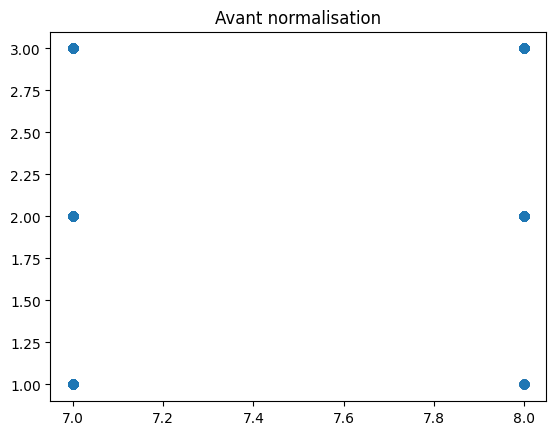

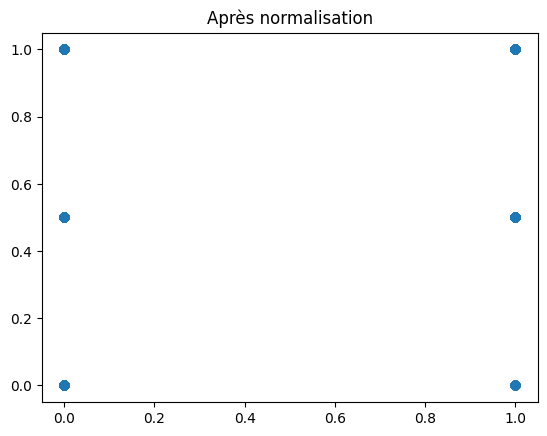

In [37]:
#b) Visualisation avant/après normalisation
plt.scatter(df['Age_Categories'], df['Income'])
plt.title("Avant normalisation")
plt.show()

plt.scatter(df['Age_normalized'], df['Income_normalized'])
plt.title("Après normalisation")
plt.show()

In [ ]:
#normaliser toutes les colonnes numériques:

from sklearn.preprocessing import MinMaxScaler

# Sélectionner uniquement les colonnes numériques
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

# Créer le scaler
scaler = MinMaxScaler()

# Appliquer la normalisation
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Vérifier
print(df.head())

         ID    Gender  Age_Categories  Income  Marital_Status  Carer  Parent  \
0  0.000000  0.970874             1.0     0.0        0.962617    0.0     1.0   
1  0.000244  0.980583             1.0     1.0        0.990654    0.0     1.0   
2  0.000488  0.970874             0.0     0.5        0.962617    0.0     1.0   
3  0.000997  0.980583             0.0     0.5        0.990654    0.0     1.0   
4  0.001098  0.970874             0.0     0.0        0.934579    0.0     0.0   

   UCLA_Single_Frequency  UCLA_Comp_Often  UCLA_Leftout_Often  ...  \
0               0.961538             0.00                0.00  ...   
1               0.990385             1.00                1.00  ...   
2               0.980769             0.75                0.50  ...   
3               0.980769             0.75                0.25  ...   
4               1.000000             0.75                0.25  ...   

   When_Adult  When_Mid_Life  When_Older_Adult  UCLA3_tot  Other_times_count  \
0         0.0     

In [42]:
#normaliser toutes les colonnes numériques:
from sklearn.preprocessing import MinMaxScaler

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

scaler = MinMaxScaler()

df_normalized = df.copy()
df_normalized[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print(df_normalized.head())

         ID    Gender  Age_Categories  Income  Marital_Status  Carer  Parent  \
0  0.000000  0.970874             1.0     0.0        0.962617    0.0     1.0   
1  0.000244  0.980583             1.0     1.0        0.990654    0.0     1.0   
2  0.000488  0.970874             0.0     0.5        0.962617    0.0     1.0   
3  0.000997  0.980583             0.0     0.5        0.990654    0.0     1.0   
4  0.001098  0.970874             0.0     0.0        0.934579    0.0     0.0   

   UCLA_Single_Frequency  UCLA_Comp_Often  UCLA_Leftout_Often  ...  \
0               0.961538             0.00                0.00  ...   
1               0.990385             1.00                1.00  ...   
2               0.980769             0.75                0.50  ...   
3               0.980769             0.75                0.25  ...   
4               1.000000             0.75                0.25  ...   

   When_Adult  When_Mid_Life  When_Older_Adult  UCLA3_tot  Other_times_count  \
0         0.0     

In [43]:
# Vérifier les statistiques après normalisation:

print(df_normalized[numeric_cols].describe())

                ID       Gender  Age_Categories       Income  Marital_Status  \
count  6708.000000  6708.000000     6708.000000  6708.000000     6708.000000   
mean      0.511371     0.977801        0.170543     0.658617        0.952445   
std       0.281774     0.012780        0.376137     0.326215        0.137237   
min       0.000000     0.000000        0.000000     0.000000        0.000000   
25%       0.288194     0.970874        0.000000     0.500000        0.962617   
50%       0.551220     0.980583        0.000000     0.500000        0.981308   
75%       0.730557     0.980583        0.000000     1.000000        0.990654   
max       1.000000     1.000000        1.000000     1.000000        1.000000   

             Carer       Parent  UCLA_Single_Frequency  UCLA_Comp_Often  \
count  6708.000000  6708.000000            6708.000000      6708.000000   
mean      0.076178     0.725701               0.881288         0.458296   
std       0.265302     0.446194               0.293549

In [44]:
#4. PCA (Réduction de dimension)
#a) Sélectionnez les colonnes numériques

numeric_cols = df.select_dtypes(include=['int64','float64']).columns
X = df[numeric_cols]

In [45]:
#b) Normalisation
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [46]:
#c) Applicateur PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=principal_components,
                      columns=['PC1','PC2'])

print(pca_df.head())

        PC1       PC2
0 -2.672328 -1.395326
1  2.724783 -1.423242
2  3.247037  2.649652
3 -1.513913 -1.493536
4  4.109036  0.869566


In [47]:
# d) Explication de la variance
print("Valeurs propres :", pca.explained_variance_)
print("Variance expliquée :", pca.explained_variance_ratio_)
print("Variance totale expliquée :", pca.explained_variance_ratio_.sum())


Valeurs propres : [5.52484697 3.35714429]
Variance expliquée : [0.20459346 0.12432014]
Variance totale expliquée : 0.32891359908200407


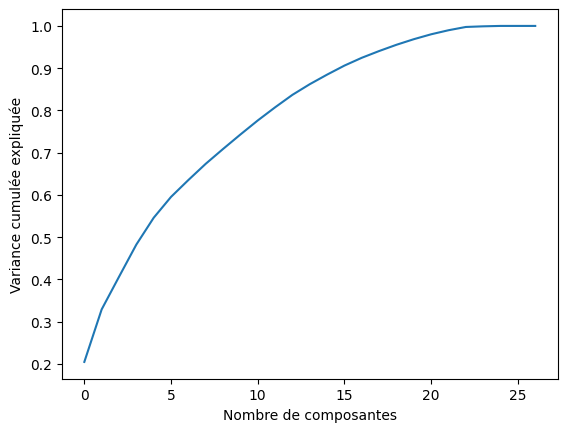

In [52]:
# recherche des combinaisons de composantes garder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_full = PCA()
pca_full.fit(X_scaled)

plt.plot(pca_full.explained_variance_ratio_.cumsum())
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance cumulée expliquée")
plt.show()

In [ ]:
#la surveillance automatique 80% de la variance expliquée
pca = PCA(n_components=0.80)
X_pca = pca.fit_transform(X_scaled)

print("Nombre de composantes choisies :", pca.n_components_)
print("Variance totale expliquée :", pca.explained_variance_ratio_.sum())

Nombre de composantes choisies : 12
Variance totale expliquée : 0.8072930392071511


In [ ]:
# remarque :Les deux premières composantes ne sont pas explicites, avec 33,89% de la variance totale. Cela indique que l'information est répartie sur plusieurs dimensions. Nous avons donc augmenté le nom des composants afin d'atteindre au moins 80% d'écart exprimé.

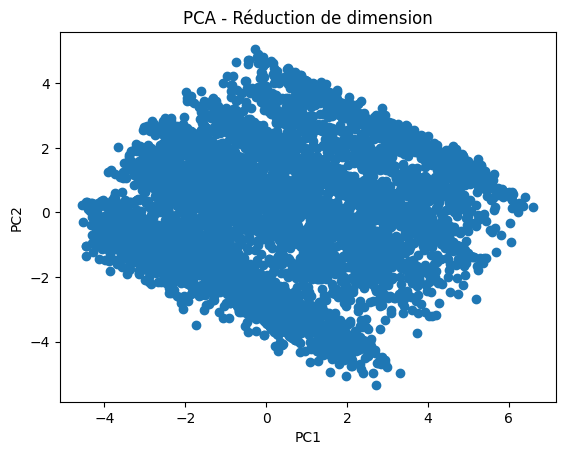

In [53]:
# e) Visualisation de l'ACP

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(pca_df['PC1'], pca_df['PC2'])
plt.title("PCA - Réduction de dimension")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

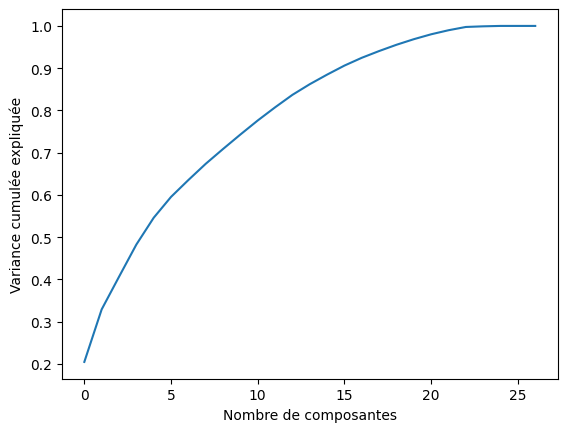

In [54]:
# f) Choix du nombre de composantes
pca_full = PCA()
pca_full.fit(X_scaled)

plt.plot(pca_full.explained_variance_ratio_.cumsum())
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance cumulée expliquée")
plt.show()